In [3]:
import pandas as pd
import numpy as np
from functions import *
X_train_orig = pd.read_csv('../data/X_train.csv', index_col='id')
X_train_filtered = filter_signal(X_train_orig)
X_test_orig = pd.read_csv('../data/X_test.csv', index_col='id')
X_test_filtered = filter_signal(X_test_orig)
y_train_orig = pd.read_csv('../data/y_train.csv', index_col='id')

In [4]:
print("Median number of entries in each times series: ", np.median(np.sum(X_train_filtered.notna(), axis=1)))
print("Minimum number of entries in each times series: ", np.min(np.sum(X_train_filtered.notna(), axis=1)))
print("Size of training data: ", len(X_train_orig))
print(y_train_orig.value_counts())

Median number of entries in each times series:  8370.0
Minimum number of entries in each times series:  2490
Size of training data:  5117
y
0    3030
2    1474
1     443
3     170
dtype: int64


# I shouldnt resample the validation set or test set for algorithm

In [5]:
#Padding the sequence with the values in last row to max length
to_pad = 8400 # cut the sequence and impute the missing entries until all have this length
steps = 20 # to reduce time series length on every timepoint is taken
split = 4000 # to create test set with known label

# choose the data to actually train on (after padding)
X_train = X_train_filtered
X_test = X_test_filtered
y_train = y_train_orig

In [6]:
# balance classes
from sklearn.utils import resample
df_1=X_train[y_train["y"]==1]
df_2=X_train[y_train["y"]==2]
df_3=X_train[y_train["y"]==3]
df_0=X_train[y_train["y"]==0]

df_1_upsample=resample(df_1,replace=True,n_samples=3000,random_state=123)
df_2_upsample=resample(df_2,replace=True,n_samples=3000,random_state=124)
df_3_upsample=resample(df_3,replace=True,n_samples=3000,random_state=125)

X_train=pd.concat([df_0,df_1_upsample,df_2_upsample,df_3_upsample],axis=0)
y_train=pd.DataFrame([0]*3030+[1]*3000+[2]*3000+[3]*3000)

In [7]:
# shuffle data
idx = np.random.permutation(len(X_train))
X_train = X_train.iloc[idx]
y_train = y_train.iloc[idx]


X_train_padded = pd.DataFrame(np.ones((len(X_train),to_pad)))
for i in range(len(X_train)):
    one_seq = X_train.iloc[i,0:to_pad].dropna()
    len_one_seq = len(one_seq)
    last_val = one_seq[-1]
    n = to_pad - len_one_seq
   
    to_concat = np.repeat(one_seq[-1], n)
    new_one_seq = np.concatenate([one_seq, to_concat])
    X_train_padded.iloc[i,:] = new_one_seq

X_test_padded = pd.DataFrame(np.ones((len(X_test),to_pad)))
for i in range(len(X_test)):
    one_seq = X_test.iloc[i,0:to_pad].dropna()
    len_one_seq = len(one_seq)
    last_val = one_seq[-1]
    n = to_pad - len_one_seq
   
    to_concat = np.repeat(one_seq[-1], n)
    new_one_seq = np.concatenate([one_seq, to_concat])
    X_test_padded.iloc[i,:] = new_one_seq

# validation sample actually not needed for second model
from sklearn.model_selection import train_test_split
train, validation, train_target, validation_target = train_test_split(X_train_padded.iloc[0:split,::steps], y_train.iloc[0:split,:], test_size=0.33, random_state=42)

# creat test set with labels
test = X_train_padded.iloc[split:,::steps]
test_target = y_train.iloc[split:,:]

# get data in right dimension
train = np.array(train).reshape((train.shape[0], train.shape[1], 1))
validation = np.array(validation).reshape((validation.shape[0], validation.shape[1], 1))
test = np.array(test).reshape((test.shape[0], test.shape[1], 1))

In [8]:
# cnn lstm model
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers import LSTM
from keras.layers import TimeDistributed
from keras.layers import Normalization
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import MaxPooling1D
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.optimizers import Adam
from keras.models import load_model
from keras.callbacks import ModelCheckpoint

In [9]:
# classes = len(np.unique(train_target))

# model = Sequential()
# model.add(LSTM(50, input_shape=(train_target.shape[1], 1)))
# model.add(Dropout(0.5))
# model.add(Dense(100, activation='relu'))
# model.add(Dense(classes, activation='softmax'))
# model.summary()

In [10]:
# adam = Adam(learning_rate=0.001)
# chk = ModelCheckpoint('best_model.pkl', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
# model.compile(loss='sparse_categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
# model.fit(train, train_target, epochs=10, batch_size=200, callbacks=[chk], validation_data=(validation,validation_target))


In [11]:
# #loading the model and checking accuracy on the test data
# model = load_model('best_model.pkl')

# from sklearn.metrics import f1_score
# predict_x=model.predict(test) 
# classes_x=np.argmax(predict_x,axis=1)
# f1_score(test_target, classes_x, average='micro')

In [12]:
from tensorflow import keras
def make_model(input_shape):
    input_layer = keras.layers.Input(input_shape)
    normalisation_layer = Normalization()(input_layer)

    conv0 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(normalisation_layer) # , kernel_regularizer='l2'
    conv0 = keras.layers.BatchNormalization()(conv0)
    conv0 = keras.layers.ReLU()(conv0)

    conv1 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv0) 
    conv1 = keras.layers.BatchNormalization()(conv1)
    conv1 = keras.layers.ReLU()(conv1)

    conv2 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv1)
    conv2 = keras.layers.BatchNormalization()(conv2)
    conv2 = keras.layers.ReLU()(conv2)
    
    conv3 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv2)
    conv3 = keras.layers.BatchNormalization()(conv3)
    conv3 = keras.layers.ReLU()(conv3)

    conv4 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv3)
    conv4 = keras.layers.BatchNormalization()(conv4)
    conv4 = keras.layers.ReLU()(conv4)

    conv5 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv4)
    conv5 = keras.layers.BatchNormalization()(conv5)
    conv5 = keras.layers.ReLU()(conv5)

    conv6 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv5)
    conv6 = keras.layers.BatchNormalization()(conv6)
    conv6 = keras.layers.ReLU()(conv6)

    conv7 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv6)
    conv7 = keras.layers.BatchNormalization()(conv7)
    conv7 = keras.layers.ReLU()(conv7)

    # dropout = keras.layers.Dropout(0.5)(conv3)
    # dropout = keras.layers.Dense(25)(dropout)

    gap = keras.layers.GlobalAveragePooling1D()(conv5)

    output_layer = keras.layers.Dense(4, activation="softmax")(gap)

    return keras.models.Model(inputs=input_layer, outputs=output_layer)


model = make_model(input_shape=train.shape[1:])
# keras.utils.plot_model(model, show_shapes=True)
model.summary()

Metal device set to: Apple M1 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 420, 1)]          0         
_________________________________________________________________
normalization (Normalization (None, 420, 1)            3         
_________________________________________________________________
conv1d (Conv1D)              (None, 420, 64)           384       
_________________________________________________________________
batch_normalization (BatchNo (None, 420, 64)           256       
_________________________________________________________________
re_lu (ReLU)                 (None, 420, 64)           0         
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 420, 64)           20544     
______________________________________________

2021-11-26 19:41:23.355845: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2021-11-26 19:41:23.356157: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [13]:
epochs = 500
batch_size = 50

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.h5", save_best_only=True, monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=20, min_lr=0.00001
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, verbose=1),
]
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)
history = model.fit(
    X_train_padded.iloc[0:split,::steps],
    y_train.iloc[0:split,:],
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    validation_split=0.2,
    verbose=1,
)

2021-11-26 19:41:23.520715: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)
2021-11-26 19:41:23.522732: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


Epoch 1/500


2021-11-26 19:41:23.941159: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


63/64 [============================>.] - ETA: 0s - loss: 3.2172 - sparse_categorical_accuracy: 0.5286

2021-11-26 19:41:25.793235: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


64/64 [==============================] - 2s 25ms/step - loss: 3.2040 - sparse_categorical_accuracy: 0.5312 - val_loss: 2.7373 - val_sparse_categorical_accuracy: 0.2637
Epoch 2/500
64/64 [==============================] - 1s 20ms/step - loss: 1.9631 - sparse_categorical_accuracy: 0.6331 - val_loss: 2.0447 - val_sparse_categorical_accuracy: 0.5163
Epoch 3/500
64/64 [==============================] - 1s 21ms/step - loss: 1.4827 - sparse_categorical_accuracy: 0.6472 - val_loss: 1.7694 - val_sparse_categorical_accuracy: 0.4612
Epoch 4/500
64/64 [==============================] - 1s 20ms/step - loss: 1.2454 - sparse_categorical_accuracy: 0.6750 - val_loss: 1.7835 - val_sparse_categorical_accuracy: 0.3912
Epoch 5/500
64/64 [==============================] - 1s 20ms/step - loss: 1.1549 - sparse_categorical_accuracy: 0.6562 - val_loss: 2.7731 - val_sparse_categorical_accuracy: 0.2862
Epoch 6/500
64/64 [==============================] - 1s 20ms/step - loss: 1.0447 - sparse_categorical_accuracy: 

In [14]:
model = keras.models.load_model("best_model.h5")

test_loss, test_acc = model.evaluate(test,test_target)

print("Test accuracy", test_acc)
print("Test loss", test_loss)

 14/251 [>.............................] - ETA: 1s - loss: 0.5730 - sparse_categorical_accuracy: 0.8839

2021-11-26 19:45:39.928037: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


251/251 [==============================] - 3s 10ms/step - loss: 0.5356 - sparse_categorical_accuracy: 0.8823
Test accuracy 0.8823163509368896
Test loss 0.5355859398841858


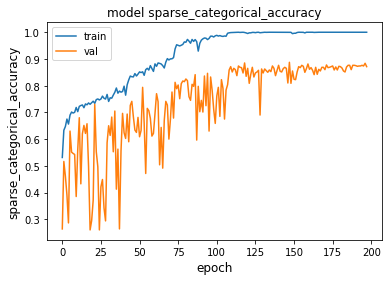

In [15]:
metric = "sparse_categorical_accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()

In [16]:
from sklearn.metrics import f1_score
predict_x=model.predict(test) 
classes_x=np.argmax(predict_x,axis=1)
f1_score(test_target, classes_x, average='micro')

2021-11-26 19:45:42.675362: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


0.8823163138231631

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(test_target, classes_x))
print("Confusion Matrix:\n", confusion_matrix(test_target, classes_x))

              precision    recall  f1-score   support

           0       0.79      0.86      0.82      2011
           1       0.95      0.92      0.94      2027
           2       0.83      0.75      0.79      2004
           3       0.96      1.00      0.98      1988

    accuracy                           0.88      8030
   macro avg       0.88      0.88      0.88      8030
weighted avg       0.88      0.88      0.88      8030

Confusion Matrix:
 [[1726   26  218   41]
 [  53 1872   92   10]
 [ 389   76 1508   31]
 [   9    0    0 1979]]


In [21]:
# predict final test set
y_test = pd.DataFrame({'id' : range(X_test_padded.shape[0])})
predict_x=model.predict(X_test_padded.iloc[:,::steps]) 
y_test['y'] = np.argmax(predict_x,axis=1)
y_test.to_csv('../out/y_test.csv', index=False)

In [22]:
print(y_test['y'].value_counts())

0    2142
2     883
1     238
3     148
Name: y, dtype: int64
